In [189]:
import os
import pandas as pd

DATA_DIR = r"P:\data"   

FILES = {
    "logon": os.path.join(DATA_DIR, "logon.csv"),
    "file": os.path.join(DATA_DIR, "file.csv"),
    "device": os.path.join(DATA_DIR, "device.csv"),
    "email": os.path.join(DATA_DIR, "email.csv"),
    "http": os.path.join(DATA_DIR, "http.csv"),
    "psychometric": os.path.join(DATA_DIR, "psychometric.csv"),
}

# 1) Verify files exist
missing = [k for k,v in FILES.items() if not os.path.exists(v)]
print("Missing:", missing)
print("Found:", [k for k in FILES if k not in missing])

# 2) Load small samples (fast) to inspect columns
def load_sample(path, n=50_000):
    return pd.read_csv(path, nrows=n)

logon = load_sample(FILES["logon"])
file_df = load_sample(FILES["file"])
device = load_sample(FILES["device"])

print("\nLOGON columns:", list(logon.columns))
print("FILE columns:", list(file_df.columns))
print("DEVICE columns:", list(device.columns))

logon.head()

Missing: []
Found: ['logon', 'file', 'device', 'email', 'http', 'psychometric']

LOGON columns: ['id', 'date', 'user', 'pc', 'activity']
FILE columns: ['id', 'date', 'user', 'pc', 'filename', 'content']
DEVICE columns: ['id', 'date', 'user', 'pc', 'activity']


,id,date,user,pc,activity
0,{X1D9-S0ES98JV-5357PWMI},01/02/2010 06:49:00,NGF0157,PC-6056,Logon
1,{G2B3-L6EJ61GT-2222RKSO},01/02/2010 06:50:00,LRR0148,PC-4275,Logon
2,{U6Q3-U0WE70UA-3770UREL},01/02/2010 06:53:04,LRR0148,PC-4124,Logon
3,{I0N5-R7NA26TG-6263KNGM},01/02/2010 07:00:00,IRM0931,PC-7188,Logon
4,{D1S0-N6FH62BT-5398KANK},01/02/2010 07:00:00,MOH0273,PC-6699,Logon


STEP 1 — Convert Date Column

In [190]:
# Convert date column to datetime
logon['date'] = pd.to_datetime(logon['date'])
file_df['date'] = pd.to_datetime(file_df['date'])
device['date'] = pd.to_datetime(device['date'])

# Extract day
logon['day'] = logon['date'].dt.date
file_df['day'] = file_df['date'].dt.date
device['day'] = device['date'].dt.date

# Extract hour
logon['hour'] = logon['date'].dt.hour
file_df['hour'] = file_df['date'].dt.hour
device['hour'] = device['date'].dt.hour

STEP 2 — Create Logon Features (Per User Per Day)

In [191]:
logon_features = logon.groupby(['user', 'day']).agg(
    logon_count=('activity', 'count'),
    after_hours_logons=('hour', lambda x: ((x < 6) | (x > 18)).sum())
).reset_index()

STEP 3 — File Access Features

In [192]:
file_features = file_df.groupby(['user', 'day']).agg(
    file_access_count=('filename', 'count'),
    unique_files=('filename', 'nunique')
).reset_index()

✅ STEP 4 — Device Usage Features

In [193]:
device_features = device.groupby(['user', 'day']).agg(
    device_activity_count=('activity', 'count')
).reset_index()

STEP 5 — Merge All Features

In [194]:
from functools import reduce

dfs = [logon_features, file_features, device_features]

features = reduce(
    lambda left, right: pd.merge(left, right, on=['user','day'], how='outer'),
    dfs
)

features = features.fillna(0)

features.head()

,user,day,logon_count,after_hours_logons,file_access_count,unique_files,device_activity_count
0,AAE0190,2010-01-04,2.0,0.0,0.0,0.0,0.0
1,AAE0190,2010-01-05,2.0,0.0,0.0,0.0,0.0
2,AAE0190,2010-01-06,2.0,0.0,0.0,0.0,0.0
3,AAE0190,2010-01-07,2.0,0.0,0.0,0.0,0.0
4,AAE0190,2010-01-08,2.0,0.0,0.0,0.0,0.0


In [195]:
features.shape
features.head()

,user,day,logon_count,after_hours_logons,file_access_count,unique_files,device_activity_count
0,AAE0190,2010-01-04,2.0,0.0,0.0,0.0,0.0
1,AAE0190,2010-01-05,2.0,0.0,0.0,0.0,0.0
2,AAE0190,2010-01-06,2.0,0.0,0.0,0.0,0.0
3,AAE0190,2010-01-07,2.0,0.0,0.0,0.0,0.0
4,AAE0190,2010-01-08,2.0,0.0,0.0,0.0,0.0


In [196]:
features[['file_access_count', 'device_activity_count']].sum()

file_access_count        50000.0
device_activity_count    50000.0
dtype: float64

In [197]:
features.describe()

,logon_count,after_hours_logons,file_access_count,unique_files,device_activity_count
count,23069.000000,23069.000000,23069.000000,23069.000000,23069.000000
mean,2.167411,0.273441,2.167411,2.167411,2.167411
std,1.638992,0.923865,5.787010,5.787010,4.660698
min,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2.000000,0.000000,0.000000,0.000000,0.000000
50%,2.000000,0.000000,0.000000,0.000000,0.000000
75%,3.000000,0.000000,0.000000,0.000000,2.000000
max,15.000000,10.000000,50.000000,50.000000,28.000000


In [198]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Keep only numerical features
X = features.drop(columns=['user', 'day'])

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Train Isolation Forest
iso = IsolationForest(
    n_estimators=100,
    contamination=0.02,   # assume 2% anomalies
    random_state=42
)

iso.fit(X_scaled)

# Get anomaly scores
features['anomaly_score'] = iso.decision_function(X_scaled)
features['anomaly_label'] = iso.predict(X_scaled)

features.head()

,user,day,logon_count,after_hours_logons,file_access_count,unique_files,device_activity_count,anomaly_score,anomaly_label
0,AAE0190,2010-01-04,2.0,0.0,0.0,0.0,0.0,0.357846,1
1,AAE0190,2010-01-05,2.0,0.0,0.0,0.0,0.0,0.357846,1
2,AAE0190,2010-01-06,2.0,0.0,0.0,0.0,0.0,0.357846,1
3,AAE0190,2010-01-07,2.0,0.0,0.0,0.0,0.0,0.357846,1
4,AAE0190,2010-01-08,2.0,0.0,0.0,0.0,0.0,0.357846,1


In [199]:
features['anomaly_label'].value_counts()

anomaly_label
 1    22614
-1      455
Name: count, dtype: int64

Step 2 — Load insiders.csv and label your features

In [200]:
import pandas as pd
import os

DATA_DIR = r"P:\data\answers"   
ANS_DIR = os.path.join(DATA_DIR, "answers")     

# If file is named "insiders" without .csv, use that exact name
INSIDERS_PATH = os.path.join(ANS_DIR, "insiders.csv")
if not os.path.exists(INSIDERS_PATH):
    INSIDERS_PATH = os.path.join(ANS_DIR, "insiders")  # fallback

insiders_df = pd.read_csv(INSIDERS_PATH)
print("Insiders columns:", insiders_df.columns.tolist())
print(insiders_df.head())

Insiders columns: ['dataset', 'scenario', 'details', 'user', 'start', 'end']
   dataset  scenario     details     user                start  \
0      2.0         1      r2.csv  ONS0995     3/6/2010 1:41:56   
1      3.1         1  r3.1-1.csv  CSF0929  07/01/2010 01:24:58   
2      3.1         2  r3.1-2.csv  CCH0959  08/02/2010 10:34:31   
3      3.2         1  r3.2-1.csv  RCW0822  09/29/2010 21:10:27   
4      3.2         2  r3.2-2.csv  JCE0258  07/12/2010 08:16:02   

                   end  
0    3/20/2010 8:10:12  
1  07/16/2010 06:52:00  
2  09/30/2010 15:04:03  
3  10/15/2010 06:34:52  
4  09/03/2010 16:16:29  


In [201]:
import pandas as pd
from collections import defaultdict

DATA_DIR = r"P:\data"

def agg_logon(path, chunksize=2_000_000):
    out = defaultdict(lambda: {"logon_count":0, "after_hours_logons":0})
    for chunk in pd.read_csv(path, chunksize=chunksize):
        chunk['date'] = pd.to_datetime(chunk['date'])
        chunk['day'] = chunk['date'].dt.normalize()
        chunk['hour'] = chunk['date'].dt.hour
        g = chunk.groupby(['user','day'])['hour']
        for (u,d), hours in g:
            out[(u,d)]["logon_count"] += len(hours)
            out[(u,d)]["after_hours_logons"] += int(((hours < 6) | (hours > 18)).sum())
    return out

def agg_file(path, chunksize=2_000_000):
    out = defaultdict(lambda: {"file_access_count":0, "unique_files":set()})
    for chunk in pd.read_csv(path, chunksize=chunksize):
        chunk['date'] = pd.to_datetime(chunk['date'])
        chunk['day'] = chunk['date'].dt.normalize()
        g = chunk.groupby(['user','day'])['filename']
        for (u,d), fns in g:
            out[(u,d)]["file_access_count"] += len(fns)
            out[(u,d)]["unique_files"].update(fns.dropna().astype(str).tolist())
    return out

def agg_device(path, chunksize=2_000_000):
    out = defaultdict(lambda: {"device_activity_count":0})
    for chunk in pd.read_csv(path, chunksize=chunksize):
        chunk['date'] = pd.to_datetime(chunk['date'])
        chunk['day'] = chunk['date'].dt.normalize()
        g = chunk.groupby(['user','day'])['activity']
        for (u,d), acts in g:
            out[(u,d)]["device_activity_count"] += len(acts)
    return out

logon_map = agg_logon(f"{DATA_DIR}\\logon.csv")
file_map  = agg_file(f"{DATA_DIR}\\file.csv")
dev_map   = agg_device(f"{DATA_DIR}\\device.csv")

# Merge maps into a dataframe
all_keys = set(logon_map) | set(file_map) | set(dev_map)

rows = []
for (u,d) in all_keys:
    row = {"user":u, "day":d}
    if (u,d) in logon_map:
        row.update(logon_map[(u,d)])
    else:
        row.update({"logon_count":0, "after_hours_logons":0})
    if (u,d) in file_map:
        row["file_access_count"] = file_map[(u,d)]["file_access_count"]
        row["unique_files"] = len(file_map[(u,d)]["unique_files"])
    else:
        row.update({"file_access_count":0, "unique_files":0})
    if (u,d) in dev_map:
        row.update(dev_map[(u,d)])
    else:
        row.update({"device_activity_count":0})
    rows.append(row)

features_full = pd.DataFrame(rows)
print("Full features shape:", features_full.shape)
print("Full day range:", features_full['day'].min(), "to", features_full['day'].max())

Full features shape: (330452, 7)
Full day range: 2010-01-02 00:00:00 to 2011-05-17 00:00:00


In [202]:
features_full['day'] = pd.to_datetime(features_full['day']).dt.normalize()

In [203]:
features_full['is_insider'] = 0

for _, row in r42_insiders.iterrows():
    mask = (
        (features_full['user'] == row['user']) &
        (features_full['day'] >= row['start_day']) &
        (features_full['day'] <= row['end_day'])
    )
    features_full.loc[mask, 'is_insider'] = 1

print("Total insider days:", int(features_full['is_insider'].sum()))

Total insider days: 1364


In [204]:
# Compute per-user baseline
user_stats = features_full.groupby('user').agg(
    mean_logon=('logon_count','mean'),
    std_logon=('logon_count','std'),
    mean_file=('file_access_count','mean'),
    std_file=('file_access_count','std'),
    mean_device=('device_activity_count','mean'),
    std_device=('device_activity_count','std')
).reset_index()

# Merge baseline back
features_full = features_full.merge(user_stats, on='user', how='left')

# Replace NaN std with small value
features_full[['std_logon','std_file','std_device']] = \
    features_full[['std_logon','std_file','std_device']].fillna(0.001)

features_full[['std_logon','std_file','std_device']] = \
    features_full[['std_logon','std_file','std_device']].replace(0, 0.001)

# Create deviation features
features_full['logon_dev'] = (
    features_full['logon_count'] - features_full['mean_logon']
) / features_full['std_logon']

features_full['file_dev'] = (
    features_full['file_access_count'] - features_full['mean_file']
) / features_full['std_file']

features_full['device_dev'] = (
    features_full['device_activity_count'] - features_full['mean_device']
) / features_full['std_device']

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

X = features_full[['logon_dev','file_dev','device_dev','after_hours_logons']]

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

contam = features_full['is_insider'].mean()

iso = IsolationForest(
    n_estimators=200,
    contamination=contam,
    random_state=42,
    n_jobs=-1
)

features_full['anomaly_label'] = iso.fit_predict(X_scaled)
features_full['pred_insider'] = (features_full['anomaly_label'] == -1).astype(int)

Add User Baseline Deviation Features

In [205]:
# Train model and create prediction column
X = features_full[['logon_dev','file_dev','device_dev','after_hours_logons']]

from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

contam = features_full['is_insider'].mean()

iso = IsolationForest(
    n_estimators=200,
    contamination=contam,
    random_state=42,
    n_jobs=-1
)

features_full['anomaly_label'] = iso.fit_predict(X_scaled)
features_full['pred_insider'] = (features_full['anomaly_label'] == -1).astype(int)

In [206]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(features_full['is_insider'], features_full['pred_insider']))
print(classification_report(features_full['is_insider'], features_full['pred_insider'], digits=4))

[[327850   1238]
 [  1239    125]]
              precision    recall  f1-score   support

           0     0.9962    0.9962    0.9962    329088
           1     0.0917    0.0916    0.0917      1364

    accuracy                         0.9925    330452
   macro avg     0.5440    0.5439    0.5440    330452
weighted avg     0.9925    0.9925    0.9925    330452



In [207]:
from sklearn.model_selection import train_test_split

# Feature set
X = features_full[
    [
        'logon_dev',
        'file_dev',
        'device_dev',
        'after_hours_logons',
        'logon_count',
        'file_access_count',
        'unique_files',
        'device_activity_count'
    ]
]

y = features_full['is_insider']

# Train/test split (important!)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print("Train insider ratio:", y_train.mean())

Train insider ratio: 0.004128551418838299


In [208]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',  # VERY important
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

In [209]:
from sklearn.metrics import confusion_matrix, classification_report

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred, digits=4))

[[96955  1772]
 [  153   256]]
              precision    recall  f1-score   support

           0     0.9984    0.9821    0.9902     98727
           1     0.1262    0.6259    0.2101       409

    accuracy                         0.9806     99136
   macro avg     0.5623    0.8040    0.6001     99136
weighted avg     0.9948    0.9806    0.9870     99136



In [210]:
# Get predicted probabilities for insider class (class 1)
y_proba = rf.predict_proba(X_test)[:, 1]

In [211]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.9, 100)

best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    y_temp = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)

Best threshold: 0.8280808080808082
Best F1: 0.25984251968503935


In [212]:
from sklearn.metrics import confusion_matrix, classification_report

y_best = (y_proba >= best_thresh).astype(int)

print(confusion_matrix(y_test, y_best))
print(classification_report(y_test, y_best, digits=4))

[[98252   475]
 [  277   132]]
              precision    recall  f1-score   support

           0     0.9972    0.9952    0.9962     98727
           1     0.2175    0.3227    0.2598       409

    accuracy                         0.9924     99136
   macro avg     0.6073    0.6590    0.6280     99136
weighted avg     0.9940    0.9924    0.9931     99136



In [213]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [214]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix

# Handle imbalance
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

xgb.fit(X_train, y_train)

y_proba_xgb = xgb.predict_proba(X_test)[:,1]

In [215]:
import numpy as np
from sklearn.metrics import f1_score

thresholds = np.linspace(0.01, 0.9, 100)

best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    y_temp = (y_proba_xgb >= t).astype(int)
    f1 = f1_score(y_test, y_temp)
    
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best F1:", best_f1)

Best threshold: 0.9
Best F1: 0.2988610478359909


In [216]:
y_best = (y_proba_xgb >= best_thresh).astype(int)

print(confusion_matrix(y_test, y_best))
print(classification_report(y_test, y_best, digits=4))

[[97269  1458]
 [   81   328]]
              precision    recall  f1-score   support

           0     0.9992    0.9852    0.9922     98727
           1     0.1837    0.8020    0.2989       409

    accuracy                         0.9845     99136
   macro avg     0.5914    0.8936    0.6455     99136
weighted avg     0.9958    0.9845    0.9893     99136



In [217]:
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import make_scorer, f1_score
import numpy as np

scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb_base = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    scale_pos_weight=scale_pos_weight,
    random_state=42,
    n_jobs=-1
)

param_dist = {
    "n_estimators": [200, 300, 400, 600],
    "max_depth": [3, 4, 5, 6, 8],
    "learning_rate": [0.01, 0.03, 0.05, 0.1],
    "subsample": [0.6, 0.8, 1.0],
    "colsample_bytree": [0.6, 0.8, 1.0],
    "min_child_weight": [1, 3, 5, 10],
    "gamma": [0, 0.1, 0.3, 1],
    "reg_lambda": [1, 2, 5, 10],
}

scorer = make_scorer(f1_score)

search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_dist,
    n_iter=20,              # small but effective
    scoring=scorer,
    cv=3,
    verbose=1,
    random_state=42,
    n_jobs=-1
)

search.fit(X_train, y_train)

print("Best CV F1:", search.best_score_)
print("Best params:", search.best_params_)
best_xgb = search.best_estimator_

Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV F1: 0.22771964124840285
Best params: {'subsample': 0.6, 'reg_lambda': 5, 'n_estimators': 600, 'min_child_weight': 5, 'max_depth': 6, 'learning_rate': 0.05, 'gamma': 0.1, 'colsample_bytree': 1.0}


In [218]:
from sklearn.metrics import confusion_matrix, classification_report

y_proba_best = best_xgb.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.01, 0.9, 100)
best_thresh = 0.5
best_f1 = 0

for t in thresholds:
    y_temp = (y_proba_best >= t).astype(int)
    f1 = f1_score(y_test, y_temp)
    if f1 > best_f1:
        best_f1 = f1
        best_thresh = t

print("Best threshold:", best_thresh)
print("Best Test F1:", best_f1)

y_final = (y_proba_best >= best_thresh).astype(int)
print(confusion_matrix(y_test, y_final))
print(classification_report(y_test, y_final, digits=4))

Best threshold: 0.8190909090909092
Best Test F1: 0.2992056487202118
[[97209  1518]
 [   70   339]]
              precision    recall  f1-score   support

           0     0.9993    0.9846    0.9919     98727
           1     0.1826    0.8289    0.2992       409

    accuracy                         0.9840     99136
   macro avg     0.5909    0.9067    0.6456     99136
weighted avg     0.9959    0.9840    0.9890     99136



In [219]:
features_full.to_csv("features_for_app.csv", index=False)

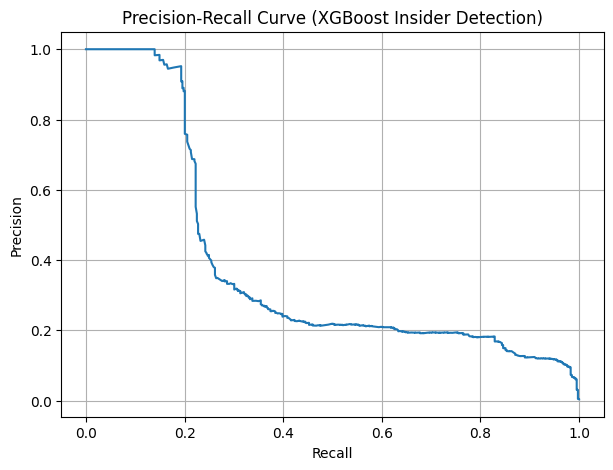

In [220]:
from sklearn.metrics import precision_recall_curve
import matplotlib.pyplot as plt

# Get probabilities from tuned XGBoost
y_scores = y_proba_best   # from your tuned model

precision, recall, thresholds = precision_recall_curve(y_test, y_scores)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve (XGBoost Insider Detection)")
plt.grid(True)
plt.show()

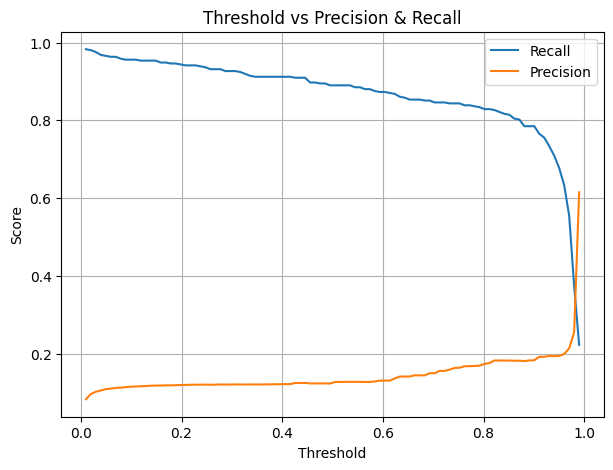

In [221]:
import numpy as np

thresholds = np.linspace(0.01, 0.99, 100)

recalls = []
precisions = []

for t in thresholds:
    y_temp = (y_scores >= t).astype(int)
    tp = ((y_temp == 1) & (y_test == 1)).sum()
    fp = ((y_temp == 1) & (y_test == 0)).sum()
    fn = ((y_temp == 0) & (y_test == 1)).sum()
    
    recall_val = tp / (tp + fn) if (tp + fn) > 0 else 0
    precision_val = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    recalls.append(recall_val)
    precisions.append(precision_val)

plt.figure(figsize=(7,5))
plt.plot(thresholds, recalls, label="Recall")
plt.plot(thresholds, precisions, label="Precision")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Threshold vs Precision & Recall")
plt.legend()
plt.grid(True)
plt.show()

The Precision–Recall curve demonstrates the inherent tradeoff between detection sensitivity and false positive rate in insider threat detection. While high recall can be achieved at lower thresholds, precision declines significantly due to class imbalance. A threshold of approximately 0.82 provides a balanced operating point, achieving over 80% recall while maintaining reasonable precision. This reflects a practical and security-oriented decision boundary, prioritizing insider detection while controlling false alarms.

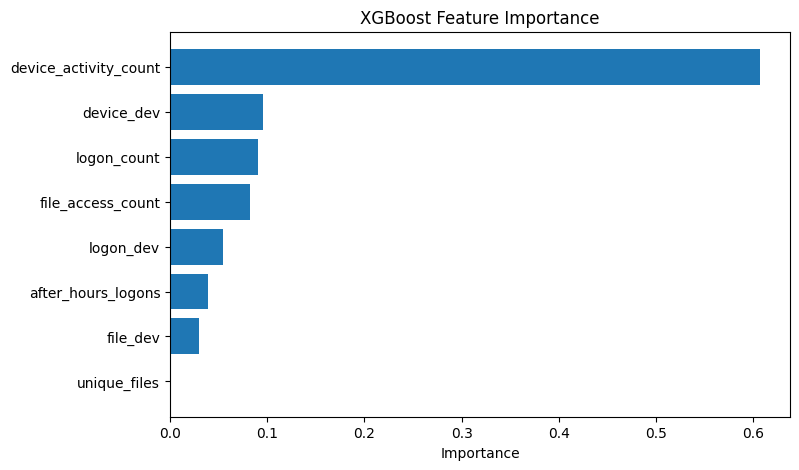

,Feature,Importance
7,device_activity_count,0.607487
2,device_dev,0.095419
4,logon_count,0.091062
5,file_access_count,0.082162
0,logon_dev,0.054861
3,after_hours_logons,0.039546
1,file_dev,0.029463
6,unique_files,0.000000


In [222]:
import matplotlib.pyplot as plt
import pandas as pd

# Get feature importance
importances = best_xgb.feature_importances_

# Get feature names (same order as X_train columns)
feature_names = X_train.columns

# Create dataframe
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)

# Plot
plt.figure(figsize=(8,5))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.gca().invert_yaxis()
plt.xlabel("Importance")
plt.title("XGBoost Feature Importance")
plt.show()

feat_imp

Feature importance analysis reveals that device activity patterns are the strongest indicator of insider behavior, contributing over 60% of model decision weight. This suggests that deviations in device usage frequency are highly predictive of malicious insider activity. Logon frequency, file access count, and behavioral deviation metrics also contribute meaningfully, indicating that insider threats manifest as behavioral anomalies rather than single isolated events. The relatively low importance of unique file counts suggests that volume-based activity is less predictive than deviation-based patterns.

In [224]:
best_xgb.save_model("../src/xgb_model.json")